In [1]:
!pip install -qU langchain
!pip install -qU langchain-google-vertexai
!pip install -qU langchain-huggingface
!pip install -qU langchain-qdrant
!pip install -qU langchain-community
!pip install -qU langgraph
!pip install fastembed
!pip install datasets
!pip install sqlalchemy
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.7/437.7 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.0/100.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3

In [13]:
!mkdir -p extracted
!7z x processed.7z -oextracted


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 219332 bytes (215 KiB)

Extracting archive: processed.7z
--
Path = processed.7z
Type = 7z
Physical Size = 219332
Headers Size = 21785
Method = LZMA:23
Solid = +
Blocks = 1

  0%      0% 810 - processed/text/blog__archives__32145__749ffd3d.txt                                                             Everything is Ok

Folders: 3
Files: 1021
Size:       2030744
Compressed: 219332


In [14]:
import os
from google.colab import userdata

# os.environ["GOOGLE_API_KEY"] = userdata.get('gemini_api_key')
os.environ["LANGSMITH_API_KEY"] = userdata.get('langsmith_api_key')
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["QDRANT_API_KEY"] = userdata.get('qdrant_api_key')

# os.environ["DATABASE_URL"] = userdata.get('DATABASE_URL')

In [15]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = 'service-account-key.json'

In [16]:
from langchain_google_vertexai import ChatVertexAI

llm = ChatVertexAI(model="gemini-2.5-flash-preview-04-17", project="gen-lang-client-0538587318")

In [17]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_qdrant import FastEmbedSparse, QdrantVectorStore, RetrievalMode
from qdrant_client import QdrantClient, models
from qdrant_client.http.models import Distance, SparseVectorParams, VectorParams

model_kwargs = {'trust_remote_code': True}
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-m3",model_kwargs=model_kwargs)
model = HuggingFaceCrossEncoder(model_name="Alibaba-NLP/gte-reranker-modernbert-base")
sparse_embeddings = FastEmbedSparse(model_name="Qdrant/bm25")

In [ ]:
# Set your Qdrant endpoint and API key
client = QdrantClient(
    url="https://1e33f4c4-874a-4210-b677-450a60926f5d.us-east-1-0.aws.cloud.qdrant.io",
    api_key=os.environ["QDRANT_API_KEY"],
)


client.recreate_collection(
      collection_name="cp-genie-faculty-info",
      vectors_config={"dense": VectorParams(size=1024, distance=Distance.COSINE)},
      sparse_vectors_config={
          "sparse": SparseVectorParams(index=models.SparseIndexParams(on_disk=False))
      },
  )
client.recreate_collection(
      collection_name="cp-genie-other-info",
      vectors_config={"dense": VectorParams(size=1024, distance=Distance.COSINE)},
      sparse_vectors_config={
          "sparse": SparseVectorParams(index=models.SparseIndexParams(on_disk=False))
      },
  )

<ipython-input-6-a41f15d39b00>:8: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(
<ipython-input-6-a41f15d39b00>:15: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


True

In [7]:
faculty_qdrant = QdrantVectorStore(
    client=client,
    collection_name="cp-genie-faculty-info",
    embedding=embeddings,
    sparse_embedding=sparse_embeddings,
    retrieval_mode=RetrievalMode.HYBRID,
    vector_name="dense",
    sparse_vector_name="sparse",
)

other_qdrant = QdrantVectorStore(
    client=client,
    collection_name="cp-genie-other-info",
    embedding=embeddings,
    sparse_embedding=sparse_embeddings,
    retrieval_mode=RetrievalMode.HYBRID,
    vector_name="dense",
    sparse_vector_name="sparse",
)

In [8]:
# # models.py
# from sqlalchemy import Column, Integer, String, DateTime, ForeignKey
# from sqlalchemy.ext.declarative import declarative_base

# Base = declarative_base()

# class Metadata(Base):
#     __tablename__ = 'metadata'

#     source_url = Column(String, primary_key=True)
#     content_type = Column(String)
#     # using last_mod as string
#     last_modified = Column(String)
#     fetch_timestamp = Column(DateTime)
#     raw_filepath = Column(String)


# class Content(Base):
#     __tablename__ = 'content'

#     id = Column(Integer, primary_key=True, autoincrement=True)
#     source_path = Column(String)
#     content = Column(String)


# class Embedded(Base):
#     __tablename__ = 'embedded'

#     id = Column(Integer, autoincrement=True, primary_key=True)
#     content_id = Column(Integer, ForeignKey('content.id'))
#     cleaned_content = Column(String)
#     last_updated = Column(DateTime)

In [9]:
# import sqlalchemy
# from sqlalchemy import create_engine, text
# from sqlalchemy.orm import sessionmaker
# from datetime import datetime

# # Replace with your Neon database connection string
# engine = create_engine(os.environ["DATABASE_URL"])
# Session = sessionmaker(bind=engine)
# session = Session()

# # Create table postgreSQL if not exist
# Base.metadata.create_all(engine)

In [10]:
# def retrieve_text_content():
#     """Retrieves text content from the specified table in Neon."""
#     try:
#         existing_content = {
#           c.id: c.content
#           for c in session.query(Content.id, Content.content).all()
#         }

#         return existing_content

#     except sqlalchemy.exc.SQLAlchemyError as e:
#         session.rollback()
#         print(f"An error occurred: {e}")
#         return []

# def retrieve_embedded_content():
#     """Retrieves embedded id that already embedded from the specified table in Neon."""
#     try:
#       results = session.query(Embedded.content_id, Embedded.last_updated).all()
#       embedded_content_id = {
#         r.content_id : r.last_updated
#         for r in results
#       }

#       return embedded_content_id

#     except sqlalchemy.exc.SQLAlchemyError as e:
#         session.rollback()
#         print(f"An error occurred: {e}")

#         return {}

# text_content_list = retrieve_text_content()
# old_embedded_content_id = retrieve_embedded_content()

## Chunking

In [24]:
from langchain.schema import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
import emoji
import re
from tqdm import tqdm
TXT_DIR = "/content/extracted/processed/text"
FACULTY_REGEX = re.compile(r"about__faculty__.*\.txt")
clean_text = lambda t: re.sub(r"\s+"," ", emoji.replace_emoji(t,"")).strip()
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100, separators=["\n\n","\n","."," "]
)

In [25]:
raw_docs = []
for fn in tqdm(os.listdir(TXT_DIR)):
    if not fn.endswith(".txt"): continue
    txt = clean_text(open(os.path.join(TXT_DIR, fn), encoding="utf-8").read())
    raw_docs.append(Document(page_content=txt, metadata={"source": fn}))

100%|██████████| 492/492 [00:00<00:00, 717.74it/s]


In [26]:
from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain
from langchain_core.output_parsers import StrOutputParser

context_prompt = PromptTemplate(
    input_variables=["full_doc", "chunk"],
    template=(
        "<document>\n{full_doc}\n</document>\n\n"
        "<chunk>\n{chunk}\n</chunk>\n\n"
        "Please give 1–2 sentences that succinctly situate this chunk within the overall document. "
        "Answer *only* with that context and nothing else."
    )
)

context_chain = context_prompt | llm | StrOutputParser()

In [27]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def process_chunk(doc, chunk):
    ctx = context_chain.invoke({
        "full_doc": doc.page_content,
        "chunk": chunk.page_content
    }).strip()
    chunk.page_content = f"{ctx}\n\n{chunk.page_content}"
    return chunk

enhanced_chunks = []

with ThreadPoolExecutor(max_workers=10) as executor:
    futures = []
    for doc in raw_docs:
        chunks = text_splitter.split_documents([doc])
        for chunk in chunks:
            futures.append(executor.submit(process_chunk, doc, chunk))

    for future in tqdm(as_completed(futures), total=len(futures), desc="Contextualizing chunks"):
        enhanced_chunks.append(future.result())

Contextualizing chunks: 100%|██████████| 1204/1204 [04:51<00:00,  4.13it/s]


In [28]:
# ───────── INDEX ─────────
fac = [c for c in enhanced_chunks if FACULTY_REGEX.match(c.metadata["source"])]
oth = [c for c in enhanced_chunks if not FACULTY_REGEX.match(c.metadata["source"])]

In [29]:
fac[0]

Document(metadata={'source': 'about__faculty__natawutn__5b00957c.txt'}, page_content='This chunk contains the complete profile information for ผศ.ดร. ณัฐวุฒิ หนูไพโรจน์, including their title, education, research interests, office, and contact details. The chunk is identical to the overall document.\n\nUpdate: 2025-02-27 14:39:23 (generated by CPMIS) ชื่อ ผศ.ดร. ณัฐวุฒิ หนูไพโรจน์ ASST.PROF.DR. NATAWUT NUPAIROJ การศึกษา Ph.D.(Computer Science,Michigan State University, USA) M.S.(Computer Science,Michigan State University, USA) B.Eng. (Computer Engineering, Chulalongkorn University) ความสนใจ Parallel Systems; Distributed Systems; Service Oriented Architecture; Networking ห้องพัก 18-08 Email natawut.n@chula.ac.th เว็บไซต์ https://www.cp.eng.chula.ac.th/~natawut/')

In [31]:
oth[0]

Document(metadata={'source': 'blog__archives__18413__50f42087.txt'}, page_content="This chunk serves as the introduction to the document, announcing the collaboration between Chulalongkorn University's Faculty of Engineering and two leading cybersecurity companies, ACIS and Cybertron, to enhance the CEDT program and provide internship opportunities for students. It details the date and location of the partnership signing ceremony and introduces the key participants.\n\nจุฬาฯ จับมือเพิ่มกับอีก 2 บริษัทชั้นนำด้าน Cyber Security ร่วมพัฒนานิสิตวิศวฯ คอมฯ หลักสูตร CEDT Tweet May 26, 2023 ความสำเร็จ จุฬาฯ จับมือเพิ่มกับอีก 2 บริษัทชั้นนำด้าน Cyber Security ร่วมพัฒนานิสิตวิศวฯ คอมฯ หลักสูตร CEDT เมื่อวันพฤหัสที่ 25 พฤษภาคม 2566 จุฬาลงกรณ์มหาวิทยาลัย โดย คณะวิศวกรรมศาสตร์ เป็นเจ้าภาพจัดพิธีลงนามข้อตกลงความร่วมมือระหว่าง จุฬาลงกรณ์มหาวิทยาลัย กับ บริษัท ACIS Professional Center จำกัด และ บริษัท Cybertron จำกัด ผู้เชี่ยวชาญด้านความมั่นคงปลอดภัยสารสนเทศ ณ คณะวิศวกรรมศาสตร์ จุฬาลงกรณ์มหาวิทยาลัย น

In [32]:
len(fac), len(oth)

(61, 1143)

In [33]:
for doc in tqdm(fac, desc="Adding faculty docs"):
    faculty_qdrant.add_documents([doc])

for doc in tqdm(oth, desc="Adding other docs"):
    other_qdrant.add_documents([doc])


Adding other docs: 100%|██████████| 1143/1143 [02:20<00:00,  8.15it/s]


In [98]:
retriever_fac = faculty_qdrant.as_retriever(search_type="similarity", k=10)
retriever_oth = other_qdrant.as_retriever(search_type="similarity", k=10)

In [99]:
reranker = CrossEncoderReranker(
    model = model,
    top_n = 10
)

retriever_fac_reranked = ContextualCompressionRetriever(
    base_retriever=retriever_fac,
    base_compressor=reranker
)

retriever_oth_reranked = ContextualCompressionRetriever(
    base_retriever=retriever_oth,
    base_compressor=reranker
)

## Eval

### Naive contextual

In [34]:
!pip install -q ragas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.5 MB/s eta 0:00:00


In [100]:
eval_llm = ChatVertexAI(model="gemini-2.5-flash-preview-04-17", project="gen-lang-client-0538587318")

In [106]:
import pandas as pd
from ragas import evaluate, EvaluationDataset

pd.set_option('display.max_colwidth', None)
import json
with open('test_questions.json', 'r') as f:
    questions = json.load(f)

In [107]:
dataset = []

for question in tqdm(questions):
    query = question['question']

    # Retrieve relevant documents
    results_fac = retriever_fac.invoke(query)
    result_oth = retriever_oth.invoke(query)
    results = results_fac + result_oth
    # Build context from retrieved docs
    context = ""
    for idx, doc in enumerate(results):
        title = doc.metadata.get("title", "")
        content = doc.page_content
        context += f"Document {idx+1}\nTitle: {title}\nContent: {content}\n\n"

    # Prepare input for LLM
    input_text = f"""Perform the Question/Answering task on the given context. If you do not know the answer, just answer that you do not know.
Also you dont need to state which document you retrieve from.
Context:\n{context}\n\nQuestion: {query}\n\nAnswer:"""

    # Get answer from chatbot
    response = llm.invoke(input_text)

    # Append to dataset list
    dataset.append({
        'user_input': question['question'],
        'retrieved_contexts': [doc.page_content for doc in results],
        'response': response.content,
        'reference': question['ground_truth'],
    })

100%|██████████| 50/50 [06:10<00:00,  7.41s/it]


In [108]:
eval_dataset = EvaluationDataset.from_list(dataset)

In [109]:
result = evaluate(eval_dataset, llm=eval_llm, embeddings=embeddings)
results_df = result.to_pandas()
display(results_df)

Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

user_input  \
0                                                                       อาจารย์ท่านใดบ้างที่จบปริญญาตรีวิศวกรรมคอมพิวเตอร์จากจุฬาฯ   
1                                                                                   อาจารย์ท่านใดบ้างที่จบการศึกษาจากประเทศญี่ปุ่น   
2                                                    อาจารย์ท่านใดบ้างที่จบการศึกษาจาก Massachusetts Institute of Technology (MIT)   
3                                                                                    อาจารย์ท่านใดบ้างที่จบการศึกษาจากประเทศอังกฤษ   
4                                                     อาจารย์ท่านใดที่มีความสนใจด้าน Artificial Intelligence หรือ Machine Learning   
5                                                                                    อาจารย์ท่านใดมีความสนใจด้าน Quantum Computing   
6                                                                อาจารย์ท่านใดมีความสนใจด้าน Image Processing หรือ Computer Vision   
7                                                                        อาจารย์ท่านใดมีความสนใจเกี่ยวกับด้าน Software Engineering   
8                                                                                   อาจารย์ท่านใดมีความสนใจในด้าน Game Development   
9                                                                            อาจารย์ท่านใดบ้างที่มีความสนใจในด้าน Computer Network   
10                                                                                 อาจารย์ท่านใดมีความสนใจในด้าน Computer Security   
11                                                                            อาจารย์ท่านใดบ้างที่มีความสนใจเกี่ยวกับด้าน Robotics   
12                                                              มีหนังสือหรือตำราใดบ้างที่แต่งโดยอาจารย์ภาควิชาวิศวกรรมคอมพิวเตอร์   
13                                                             หลักสูตร CP ใช้ระยะเวลาการศึกษากี่ปี และต้องเรียนทั้งหมดกี่หน่วยกิต   
14                                                                                                   หลักสูตร CP มีชื่อเต็มว่าอะไร   
15                                        วิธีการรับนักเรียนเข้าศึกษาต่อในภาควิชาวิศวกรรมคอมพิวเตอร์หลักสูตร CP มีกี่วิธี อะไรบ้าง   
16                            หลักสูตร CP พ.ศ.2561 กลุ่มรายวิชาบังคับเลือก (Approved electives) มีอะไรบ้าง และต้องเรียนกี่หน่วยกิต   
17                                                           หลักสูตร CP กลุ่มรายวิชาเลือก (Electives) ต้องเรียนทั้งหมดกี่หน่วยกิต   
18                                                                         รายวิชาภาษาอังกฤษที่บังคับเรียนในหลักสูตร CP มีอะไรบ้าง   
19                                                                                          ฝึกงานในหลักสูตร CP จะต้องฝึกในช่วงไหน   
20                                                                        หลักสูตร CP ปี 2 เทอม 2 จะต้องลงทะเบียนเรียนวิชาอะไรบ้าง   
21                                              วิชาเลือกของภาควิชาที่เกี่ยวข้องกับ AI, Machine Learning, Deep Learning มีอะไรบ้าง   
22                                                             วิชาเลือกของภาควิชาที่เกี่ยวข้องกับ Software Engineering มีอะไรบ้าง   
23                                            วิชาเลือกของภาควิชาที่เกี่ยวข้องกับ Image Processing หรือ Computer Vision มีอะไรบ้าง   
24                                                              หลักสูตร CEDT ใช้ระยะเวลาเรียนกี่ปี และต้องเรียนทั้งหมดกี่หน่วยกิต   
25                                                                              การเรียนการสอนในหลักสูตร CEDT มีลักษณะพิเศษอย่างไร   
26                                                                                                 หลักสูตร CEDT มีชื่อเต็มว่าอะไร   
27                                                                                             หลักสูตร CEDT เปิดรับนิสิตปีละกี่คน   
28                                                                      หลักสูตร CEDT ปี 1 เทอม 1 จะต้องลงทะเบียนเรียนวิชาอะไรบ้าง   
29                                                                              ฝึกงานสหกิจศึกษาในหล

In [110]:
import plotly.express as px
import ast
data = ast.literal_eval(str(result))

metrics = list(data.keys())
scores = list(data.values())

fig = px.bar(x=metrics, y=scores, labels={'x': 'Metric', 'y': 'Score'}, title='Metric Scores')
fig.update_layout(yaxis_range=[0, 1])

fig.show()

In [111]:
results_df.to_csv('contextual_naive.csv', index=False)

### Naive contextual with reranker

In [101]:
dataset = []

for question in tqdm(questions):
    query = question['question']

    # Retrieve relevant documents
    results_fac = retriever_fac_reranked.invoke(query)
    result_oth = retriever_oth_reranked.invoke(query)
    results = results_fac + result_oth
    # Build context from retrieved docs
    context = ""
    for idx, doc in enumerate(results):
        title = doc.metadata.get("title", "")
        content = doc.page_content
        context += f"Document {idx+1}\nTitle: {title}\nContent: {content}\n\n"

    # Prepare input for LLM
    input_text = f"""Perform the Question/Answering task on the given context. If you do not know the answer, just answer that you do not know.
Also you dont need to state which document you retrieve from.
Context:\n{context}\n\nQuestion: {query}\n\nAnswer:"""

    # Get answer from chatbot
    response = llm.invoke(input_text)

    # Append to dataset list
    dataset.append({
        'user_input': question['question'],
        'retrieved_contexts': [doc.page_content for doc in results],
        'response': response.content,
        'reference': question['ground_truth'],
    })

eval_dataset = EvaluationDataset.from_list(dataset)

100%|██████████| 50/50 [06:47<00:00,  8.14s/it]


In [102]:
result = evaluate(eval_dataset, llm=eval_llm, embeddings=embeddings)
results_df = result.to_pandas()
display(results_df)

Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

user_input  \
0                                                                       อาจารย์ท่านใดบ้างที่จบปริญญาตรีวิศวกรรมคอมพิวเตอร์จากจุฬาฯ   
1                                                                                   อาจารย์ท่านใดบ้างที่จบการศึกษาจากประเทศญี่ปุ่น   
2                                                    อาจารย์ท่านใดบ้างที่จบการศึกษาจาก Massachusetts Institute of Technology (MIT)   
3                                                                                    อาจารย์ท่านใดบ้างที่จบการศึกษาจากประเทศอังกฤษ   
4                                                     อาจารย์ท่านใดที่มีความสนใจด้าน Artificial Intelligence หรือ Machine Learning   
5                                                                                    อาจารย์ท่านใดมีความสนใจด้าน Quantum Computing   
6                                                                อาจารย์ท่านใดมีความสนใจด้าน Image Processing หรือ Computer Vision   
7                                                                        อาจารย์ท่านใดมีความสนใจเกี่ยวกับด้าน Software Engineering   
8                                                                                   อาจารย์ท่านใดมีความสนใจในด้าน Game Development   
9                                                                            อาจารย์ท่านใดบ้างที่มีความสนใจในด้าน Computer Network   
10                                                                                 อาจารย์ท่านใดมีความสนใจในด้าน Computer Security   
11                                                                            อาจารย์ท่านใดบ้างที่มีความสนใจเกี่ยวกับด้าน Robotics   
12                                                              มีหนังสือหรือตำราใดบ้างที่แต่งโดยอาจารย์ภาควิชาวิศวกรรมคอมพิวเตอร์   
13                                                             หลักสูตร CP ใช้ระยะเวลาการศึกษากี่ปี และต้องเรียนทั้งหมดกี่หน่วยกิต   
14                                                                                                   หลักสูตร CP มีชื่อเต็มว่าอะไร   
15                                        วิธีการรับนักเรียนเข้าศึกษาต่อในภาควิชาวิศวกรรมคอมพิวเตอร์หลักสูตร CP มีกี่วิธี อะไรบ้าง   
16                            หลักสูตร CP พ.ศ.2561 กลุ่มรายวิชาบังคับเลือก (Approved electives) มีอะไรบ้าง และต้องเรียนกี่หน่วยกิต   
17                                                           หลักสูตร CP กลุ่มรายวิชาเลือก (Electives) ต้องเรียนทั้งหมดกี่หน่วยกิต   
18                                                                         รายวิชาภาษาอังกฤษที่บังคับเรียนในหลักสูตร CP มีอะไรบ้าง   
19                                                                                          ฝึกงานในหลักสูตร CP จะต้องฝึกในช่วงไหน   
20                                                                        หลักสูตร CP ปี 2 เทอม 2 จะต้องลงทะเบียนเรียนวิชาอะไรบ้าง   
21                                              วิชาเลือกของภาควิชาที่เกี่ยวข้องกับ AI, Machine Learning, Deep Learning มีอะไรบ้าง   
22                                                             วิชาเลือกของภาควิชาที่เกี่ยวข้องกับ Software Engineering มีอะไรบ้าง   
23                                            วิชาเลือกของภาควิชาที่เกี่ยวข้องกับ Image Processing หรือ Computer Vision มีอะไรบ้าง   
24                                                              หลักสูตร CEDT ใช้ระยะเวลาเรียนกี่ปี และต้องเรียนทั้งหมดกี่หน่วยกิต   
25                                                                              การเรียนการสอนในหลักสูตร CEDT มีลักษณะพิเศษอย่างไร   
26                                                                                                 หลักสูตร CEDT มีชื่อเต็มว่าอะไร   
27                                                                                             หลักสูตร CEDT เปิดรับนิสิตปีละกี่คน   
28                                                                      หลักสูตร CEDT ปี 1 เทอม 1 จะต้องลงทะเบียนเรียนวิชาอะไรบ้าง   
29                                                                              ฝึกงานสหกิจศึกษาในหล

In [103]:
import plotly.express as px
import ast
data = ast.literal_eval(str(result))

metrics = list(data.keys())
scores = list(data.values())

fig = px.bar(x=metrics, y=scores, labels={'x': 'Metric', 'y': 'Score'}, title='Metric Scores')
fig.update_layout(yaxis_range=[0, 1])

fig.show()

In [105]:
results_df.to_csv('contextual_naive_wrerank.csv', index=False)

### Agentic

In [112]:
from langgraph.graph import StateGraph, END
from langchain.prompts import ChatPromptTemplate
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_core.messages import HumanMessage, ToolMessage, SystemMessage, AIMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition as prebuilt_tools_condition
from typing import List, cast
from langchain_core.documents import Document
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from typing import Literal

class State(TypedDict):
    messages: Annotated[list, add_messages]
    context: str
    query: str

In [113]:
@tool(response_format="content_and_artifact")
def retrieve_fac_info(query: str) -> tuple[str, List[Document]]:
    """
    ใช้สำหรับค้นหาข้อมูลพื้นฐานเกี่ยวกับอาจารย์ในภาควิชาวิศวกรรมคอมพิวเตอร์ จุฬาลงกรณ์มหาวิทยาลัย
    เช่น ชื่อ-นามสกุล ตำแหน่งทางวิชาการ วุฒิการศึกษา ภาควิชา หรือประวัติการสอน
    """
    retrieved_docs = retriever_fac.invoke(query)
    serialized = "\n\n".join(f"Context: {doc.page_content}" for doc in retrieved_docs)
    return serialized, retrieved_docs

@tool(response_format="content_and_artifact")
def retrieve_fac_oth(query: str) -> tuple[str, List[Document]]:
    """
    ใช้สำหรับค้นหาข้อมูลอื่น ๆ ที่เกี่ยวข้องกับภาควิชาวิศวกรรมคอมพิวเตอร์ จุฬาลงกรณ์มหาวิทยาลัย
    เช่น งานวิจัยของอาจารย์ บทความวิชาการ ข่าวกิจกรรม งานบริการวิชาการ หรือรางวัลต่าง ๆ
    """
    retrieved_docs = retriever_oth.invoke(query)
    serialized = "\n\n".join(f"Context: {doc.page_content}" for doc in retrieved_docs)
    return serialized, retrieved_docs

system_prompt = """
คุณคือ GIGI(กีกี้) ผู้ช่วยที่เป็นมิตรและเชื่อถือได้ สำหรับนิสิต อาจารย์ และบุคลากรในภาควิชาวิศวกรรมคอมพิวเตอร์ จุฬาลงกรณ์มหาวิทยาลัย
คุณมีหน้าที่ให้ข้อมูลอย่างสุภาพ กระชับ และเป็นประโยชน์
หากคุณไม่ทราบคำตอบจากบริบทที่มีอยู่ ให้เรียกใช้เครื่องมือเพื่อค้นหาข้อมูลเพิ่มเติม
คุณต้องตอบเป็นภาษาไทยเท่านั้น และควรใช้ภาษาที่ชัดเจน เข้าใจง่าย
"""


generation_prompt = ChatPromptTemplate.from_messages([
    ("system", sys_prompt),
    ("human", "Context:\n{context}\n\nHistory:\n{messages}\n\nQuery: {query}"),
])

combine_chain = create_stuff_documents_chain(llm, generation_prompt)
llm_with_tools = llm.bind_tools([retrieve_fac_info, retrieve_fac_oth])

def generate(state: State) -> dict:
    last = state["messages"][-1]
    docs_for_context = []
    if isinstance(last, ToolMessage) and hasattr(last, 'artifact'):
        docs_for_context = last.artifact if last.artifact is not None else []

    history = [m for m in state["messages"] if not isinstance(m, SystemMessage)]
    out_content = combine_chain.invoke({
        "messages": history,
        "context": docs_for_context,
        "query": state["query"],
    })
    return {"messages": [AIMessage(content=out_content.content if isinstance(out_content, AIMessage) else out_content)], "context": docs_for_context}


def agent(state: State) -> dict:
    history = state["messages"]
    response = llm_with_tools.invoke(history)
    return {"messages": [response]}

In [114]:
graph = StateGraph(State)

# --- nodes ---------------------------------------------------------
graph.add_node("agent", agent)
graph.add_node("tools", ToolNode([retrieve_fac_info, retrieve_fac_oth]))
graph.add_node("generate", generate)

graph.set_entry_point("agent")

# --- edges ---------------------------------------------------------
graph.add_conditional_edges(
    "agent",
    prebuilt_tools_condition,      # END if no tool-call else go to ToolNode
    {END: END, "tools": "tools"},
)

# after any tool call, go straight to the LLM that writes the final answer
graph.add_edge("tools", "generate")
graph.add_edge("generate", END)

chain = graph.compile()

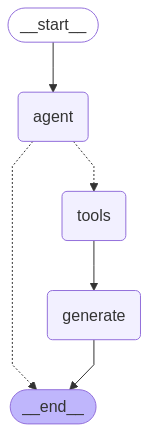

In [115]:
from IPython.display import Image, display
display(Image(chain.get_graph().draw_mermaid_png()))

In [116]:
dataset = []

for question in tqdm(questions):
    query = question['question']

    initial_state: State = {
        "messages": [{"role": "user", "content": query}],
        "context": [],
        "query": query,
    }

    final_state = chain.invoke(initial_state)
    answer = final_state.get("messages")[-1].content
    raw_context = final_state.get("context", [])
    retrieved_context = [doc.page_content for doc in raw_context]

    # print("Got final_state:", final_state)
    # print("Answer:", answer)
    # print("Context:", retrieved_context)


    # Append to dataset list
    dataset.append({
        'user_input': question['question'],
        'retrieved_contexts': retrieved_context,
        'response': answer,
        'reference': question['ground_truth'],
    })

100%|██████████| 50/50 [03:06<00:00,  3.73s/it]


In [117]:
eval_dataset = EvaluationDataset.from_list(dataset)
result = evaluate(eval_dataset, llm=eval_llm, embeddings=embeddings)
data = ast.literal_eval(str(result))
metrics = list(data.keys())
scores = list(data.values())
fig = px.bar(x=metrics, y=scores, labels={'x': 'Metric', 'y': 'Score'}, title='Metric Scores')
fig.update_layout(yaxis_range=[0, 1])
fig.show()

Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

In [118]:
fig = px.bar(x=metrics, y=scores, labels={'x': 'Metric', 'y': 'Score'}, title='Metric Scores')
fig.update_layout(yaxis_range=[0, 1])
fig.show()

In [119]:
results_df = result.to_pandas()
display(results_df)

user_input  \
0                                                                       อาจารย์ท่านใดบ้างที่จบปริญญาตรีวิศวกรรมคอมพิวเตอร์จากจุฬาฯ   
1                                                                                   อาจารย์ท่านใดบ้างที่จบการศึกษาจากประเทศญี่ปุ่น   
2                                                    อาจารย์ท่านใดบ้างที่จบการศึกษาจาก Massachusetts Institute of Technology (MIT)   
3                                                                                    อาจารย์ท่านใดบ้างที่จบการศึกษาจากประเทศอังกฤษ   
4                                                     อาจารย์ท่านใดที่มีความสนใจด้าน Artificial Intelligence หรือ Machine Learning   
5                                                                                    อาจารย์ท่านใดมีความสนใจด้าน Quantum Computing   
6                                                                อาจารย์ท่านใดมีความสนใจด้าน Image Processing หรือ Computer Vision   
7                                                                        อาจารย์ท่านใดมีความสนใจเกี่ยวกับด้าน Software Engineering   
8                                                                                   อาจารย์ท่านใดมีความสนใจในด้าน Game Development   
9                                                                            อาจารย์ท่านใดบ้างที่มีความสนใจในด้าน Computer Network   
10                                                                                 อาจารย์ท่านใดมีความสนใจในด้าน Computer Security   
11                                                                            อาจารย์ท่านใดบ้างที่มีความสนใจเกี่ยวกับด้าน Robotics   
12                                                              มีหนังสือหรือตำราใดบ้างที่แต่งโดยอาจารย์ภาควิชาวิศวกรรมคอมพิวเตอร์   
13                                                             หลักสูตร CP ใช้ระยะเวลาการศึกษากี่ปี และต้องเรียนทั้งหมดกี่หน่วยกิต   
14                                                                                                   หลักสูตร CP มีชื่อเต็มว่าอะไร   
15                                        วิธีการรับนักเรียนเข้าศึกษาต่อในภาควิชาวิศวกรรมคอมพิวเตอร์หลักสูตร CP มีกี่วิธี อะไรบ้าง   
16                            หลักสูตร CP พ.ศ.2561 กลุ่มรายวิชาบังคับเลือก (Approved electives) มีอะไรบ้าง และต้องเรียนกี่หน่วยกิต   
17                                                           หลักสูตร CP กลุ่มรายวิชาเลือก (Electives) ต้องเรียนทั้งหมดกี่หน่วยกิต   
18                                                                         รายวิชาภาษาอังกฤษที่บังคับเรียนในหลักสูตร CP มีอะไรบ้าง   
19                                                                                          ฝึกงานในหลักสูตร CP จะต้องฝึกในช่วงไหน   
20                                                                        หลักสูตร CP ปี 2 เทอม 2 จะต้องลงทะเบียนเรียนวิชาอะไรบ้าง   
21                                              วิชาเลือกของภาควิชาที่เกี่ยวข้องกับ AI, Machine Learning, Deep Learning มีอะไรบ้าง   
22                                                             วิชาเลือกของภาควิชาที่เกี่ยวข้องกับ Software Engineering มีอะไรบ้าง   
23                                            วิชาเลือกของภาควิชาที่เกี่ยวข้องกับ Image Processing หรือ Computer Vision มีอะไรบ้าง   
24                                                              หลักสูตร CEDT ใช้ระยะเวลาเรียนกี่ปี และต้องเรียนทั้งหมดกี่หน่วยกิต   
25                                                                              การเรียนการสอนในหลักสูตร CEDT มีลักษณะพิเศษอย่างไร   
26                                                                                                 หลักสูตร CEDT มีชื่อเต็มว่าอะไร   
27                                                                                             หลักสูตร CEDT เปิดรับนิสิตปีละกี่คน   
28                                                                      หลักสูตร CEDT ปี 1 เทอม 1 จะต้องลงทะเบียนเรียนวิชาอะไรบ้าง   
29                                                                              ฝึกงานสหกิจศึกษาในหล